# Анализ ассортимента методом ABC/XYZ
---

**Выполнила проекта: Флоря Виктория**  
**Дата: 06.10.2026**


---

## Тема проекта

**Анализ ассортимента интернет-магазина подарков и товаров для дома методом ABC/XYZ.**

---

## Цель проекта

Оценить структуру ассортимента и предложить правила управления товарными позициями.   
Главный вопрос проекта. Какие товары необходимо постоянно держать 
в ассортименте, какие требуют осторожного управления запасами, а какие можно рассматривать как кандидатов на сокращение или вывод – и какой потенциальный эффект даст такое решение?


---

## Задачи проекта

1. **Первичный обзор данных.** Оценить объём, структуру и типы полей, охват по времени; найти и осмысленно обработать аномалии — отмены, отрицательные количества, нулевые цены, служебные коды, дубликаты.

2. **Общая картина бизнеса.** Посчитать ключевые показатели (число SKU, заказы, покупатели, выручка, средний чек по заказу), построить помесячную динамику и оценить концентрацию выручки.

3. **ABC-анализ по выручке.** Разбить товары на категории A / B / C исходя из накопленной доли выручки.

4. **XYZ-анализ по стабильности спроса.** Для каждого SKU собрать полный ряд количества за 12 месяцев (с учётом нулевых значений) и вычислить коэффициент вариации (CV).

5. **Матрица ABC/XYZ.** Выделить 9 сегментов (AX…CZ) и рассчитать бизнес-показатели по каждому из них.

6. **Правила управления.** Определить стратегию работы для каждой группы матрицы.

7. **Перечень кандидатов на вывод.** Сформировать критерии отбора на основе ABC/XYZ и дополнительных метрик.

8. **Оценка эффекта.** Определить долю SKU и долю выручки, приходящуюся на кандидатов, и проверить устойчивость полученного решения.


## Описание данных
Источник данных: UCI Machine Learning Repository — Online Retail II  
`InvoiceNo`	 - Номер счета / заказа. Используется для подсчета заказов и выявления отмен.  
`StockCode`	- Код товарной позиции (SKU). Основной ключ товарного анализа.  
`Description`	- Описание / название товара. Нужно для интерпретации результатов.  
`Quantity`	- Количество единиц товара в операции. Используется как основа показателя спроса для XYZ.  
`InvoiceDate`	- Дата и время операции. Нужна для выбора периода и агрегации по месяцам.  
`UnitPrice`	- Цена одной единицы товара.  
`CustomerID`	- Идентификатор покупателя. Полезен для дополнительных метрик, но не обязателен для ABC.  
`Country`	    - Страна клиента. Может использоваться в дополнительном анализе.  


## 1. Загрузка библиотек

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import linregress, kruskal, mannwhitneyu, pearsonr, spearmanr
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
from statsmodels.formula.api import ols

sns.set_style('whitegrid')

## 2. Загрузка данных

In [2]:
path = r'C:\Users\dak\OneDrive\Desktop\online+retail+ii\online_retail_II.xlsx' 

d_0910 = pd.read_excel(path, sheet_name='Year 2009-2010')
d_1011 = pd.read_excel(path, sheet_name='Year 2010-2011')

# объединяем в один датафрейм
df = pd.concat([d_0910, d_1011], ignore_index=True)

print ('Размер исходной таблицы строки/столбцы:', df.shape)
df.head(5)

Размер исходной таблицы строки/столбцы: (1067371, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [3]:
print("Типы данных полей:")
print(df.dtypes, "\n")

Типы данных полей:
Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
Price                 float64
Customer ID           float64
Country                object
dtype: object 



In [4]:
# Временной диапазон 
# Преобразуем в datetime для просмотра диапазона 
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
print("Временной диапазон:")
print(f"От: {df['InvoiceDate'].min()}")
print(f"До: {df['InvoiceDate'].max()}\n")

Временной диапазон:
От: 2009-12-01 07:45:00
До: 2011-12-09 12:50:00



In [5]:
# Основные проблемы качества данных
print("ПРОБЛЕМЫ КАЧЕСТВА ДАННЫХ:")

# Пропуски
print("\n Пропуски")
print(df.isnull().sum())

# Отмены (Invoice начинается с 'C')
cancellations = df[df['Invoice'].astype(str).str.startswith('C')]
print(f"\n Отмены (Invoice начинается с 'C') ")
print(f"Количество строк с отменами: {cancellations.shape[0]}")

# Отрицательное количество (Quantity < 0)
neg_qty = df[df['Quantity'] < 0]
print(f"\n Отрицательное количество (Quantity < 0)")
print(f"Количество строк: {neg_qty.shape[0]}")

# Нулевая или отрицательная цена (Price <= 0)
zero_neg_price = df[df['Price'] <= 0]
print(f"\n Нулевая или отрицательная цена (Price <= 0)")
print(f"Количество строк: {zero_neg_price.shape[0]}")

# Дубликаты
duplicates = df.duplicated().sum()
print(f"\nДубликаты строк ")
print(f"Количество полных дубликатов: {duplicates}")

# Служебные StockCode (не товары)
# Часто в этом датасете встречаются коды POST, D, M, BANK CHARGES и т.д.
# Проверим коды, которые не являются числами или имеют специфический формат
# (Например, длиннее 5 символов или содержат буквы, не являясь стандартными)
print(f"\n Примеры нестандартных StockCode ")
# Просто выведем уникальные значения, которые не похожи на обычные 5-значные коды
non_standard_codes = df[~df['StockCode'].astype(str).str.match(r'^\d{5}[A-Z]?$')]['StockCode'].unique()
print(f"Примеры нестандартных кодов: {non_standard_codes[:20]}")

ПРОБЛЕМЫ КАЧЕСТВА ДАННЫХ:

 Пропуски
Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

 Отмены (Invoice начинается с 'C') 
Количество строк с отменами: 19494

 Отрицательное количество (Quantity < 0)
Количество строк: 22950

 Нулевая или отрицательная цена (Price <= 0)
Количество строк: 6207

Дубликаты строк 
Количество полных дубликатов: 34335

 Примеры нестандартных StockCode 
Примеры нестандартных кодов: ['POST' '79323LP' '15056BL' 'D' '79323GR' 'DCGS0058' 'DCGS0068' 'DOT'
 '72349b' '72529w' '72807c' '84797b' '84872a' '84873a' '85114b' '18096c'
 '84797a' '85014b' '85132a' '18098c']


**Всего в датасете 1 067 371 строк, 8 столбцов.**  

**Пропуски :** Пропуски: Customer ID (Идентификатор покупателя) отсутствует в ~23% строк (норма для розницы, для анализа SKU не критично). Description (Описание / название товара) — 4 382 строки (можно отбросить). Ключевые поля (Invoice, StockCode, Quantity, Price, Date) заполнены полностью.

**Отмены и возвраты:** Invoice (Номер счета / заказа) -19 494 отмены + 22 950 строк с отрицательным Quantity (Количество единиц товара в операции)  (~2% данных). Их нужно исключить, чтобы не искажать реальный спрос и выручку.

**Нулевые цены:** 6 207 строк. Это могут быть подарки или служебные операции — исключаем.

**Дубликаты:** 34 335 полных копий строк. Их необходимо удалить, иначе выручка задвоится.  

**Нестандартные StockCode:** POST, D, DOT и др. — это не товары (доставка, скидки, корректировки). Их нужно убрать из товарного анализа.

## 3. Предобработка данных

## 3.1 Выбираем период

In [6]:
#Задаем границы 12 полных месяцев
start_date = pd.Timestamp('2010-12-01')
end_date = pd.Timestamp('2011-11-30')

In [7]:
# Фильтруем данные по выбранному периоду
# Используем .copy()
df_period = df[(df['InvoiceDate'] >= start_date) & (df['InvoiceDate'] <= end_date)].copy()

# Проверяем результат
print(f"\nВыбранный период: с {df_period['InvoiceDate'].min()} по {df_period['InvoiceDate'].max()}")
print(f"Размер таблицы за 12 полных месяцев: {df_period.shape}")


Выбранный период: с 2010-12-01 08:26:00 по 2011-11-29 18:19:00
Размер таблицы за 12 полных месяцев: (535453, 8)


In [8]:
df_period.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 535453 entries, 502938 to 1038390
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      535453 non-null  object        
 1   StockCode    535453 non-null  object        
 2   Description  533911 non-null  object        
 3   Quantity     535453 non-null  int64         
 4   InvoiceDate  535453 non-null  datetime64[ns]
 5   Price        535453 non-null  float64       
 6   Customer ID  401776 non-null  float64       
 7   Country      535453 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 36.8+ MB


**В качестве периода анализа выбран интервал с декабря 2010 по ноябрь 2011.**   
Выбор обусловлен необходимостью получить 12 полных последовательных месяцев. Это критически важно для корректной оценки сезонности (полный годовой цикл) и расчета стабильности спроса (XYZ-анализ). Данные за декабрь 2011 года исключены, так как они содержат информацию только за 9 дней и могли бы исказить общую картину, создав ложное впечатление падения продаж. Использование самого свежего доступного года обеспечивает максимальную релевантность рекомендаций для текущего управления ассортиментом.  
Новый датафрейм `df_period` содержит  - 535 453 строк.

## 3.2 Удаляем дубликаты

In [9]:
# Удаляем все полные дубликаты
df_period = df_period.drop_duplicates()
print(f"Размер после удаления дубликатов: {df_period.shape}")

Размер после удаления дубликатов: (507958, 8)


## 3.3 Исключение отмен и отрицательных количеств

In [10]:
# Исключаем отмены
df_period = df_period[~df_period['Invoice'].astype(str).str.startswith('C')]

# Исключаем отрицательные Quantity
df_period = df_period[df_period['Quantity'] > 0]

print(f"Размер после удаления отмен и отрицательных Quantity: {df_period.shape}")

Размер после удаления отмен и отрицательных Quantity: (497850, 8)


Отмены (Invoice с 'C') — это возвраты. Они не являются продажами, а уменьшают выручку.  
Отрицательное Quantity без метки 'C' — это корректировки запасов, списания или ошибки ввода.    
Для анализа спроса и ассортимента нам нужны только успешные продажи, где товар был фактически куплен.  

## 3.4 Фильтрация нулевых и отрицательных цен

In [11]:
# Фильтрация нулевых и отрицательных цен
df_period = df_period[df_period['Price'] > 0]
print(f"Размер после фильтрации цен: {df_period.shape}")

Размер после фильтрации цен: (496704, 8)


Оставляем только строки, где Price > 0.  
Нулевая цена может означать бесплатные образцы, подарки, служебные операции или ошибки.  
Для анализа выручки такие строки бесполезны, а иногда и вредны (искажают среднюю цену).  

## 3.5 Обработка пропусков

In [12]:
# Удаляем строки с пропущенным Description
df_period = df_period.dropna(subset=['Description'])

print(f"Размер после удаления пропусков в Description: {df_period.shape}")
print(f"Осталось пропусков в Customer ID: {df_period['Customer ID'].isnull().sum()}")

Размер после удаления пропусков в Description: (496704, 8)
Осталось пропусков в Customer ID: 123142


Customer ID: оставляем пропуски как есть, не удаляем строки.    
Description: удаляем строки с пропущенным описанием.    

Customer ID не важен для ABC/XYZ-анализа по SKU. Мы анализируем товары, а не клиентов.  
Удаление 23% данных лишило бы нас значительной части информации о продажах.  
Без Description невозможно идентифицировать товар, поэтому такие строки удаляем.  

Итого пропусков в Description - 0, в Customer ID -  123 142.

## 3.6 Исключение нестандартных StockCode (служебных операций)

In [13]:
# Оставляем только коды, начинающиеся с 5 цифр (возможно, с буквами после)
df_period = df_period[df_period['StockCode'].astype(str).str.match(r'^\d{5}[A-Za-z]*$')]

print(f"Размер после фильтрации StockCode: {df_period.shape}")

Размер после фильтрации StockCode: (494427, 8)


## 3.7 Создание колонки Revenue и финальная проверка

In [14]:
# Создаем колонку Revenue = Quantity * Price.
# Это основа для ABC-анализа (ранжирование по выручке).

df_period['Revenue'] = df_period['Quantity'] * df_period['Price']

# Финальная проверка
print("ФИНАЛЬНЫЙ РАЗМЕР ВЫБОРКИ РЕАЛЬНЫХ ПРОДАЖ:", df_period.shape)
print("\nПроверка на отсутствие отрицательных значений:")
print(f"Quantity > 0: {(df_period['Quantity'] > 0).all()}")
print(f"Price > 0: {(df_period['Price'] > 0).all()}")
print(f"Revenue > 0: {(df_period['Revenue'] > 0).all()}")

# Сохраняем очищенный датафрейм в отдельную переменную для дальнейшего анализа
df_sales = df_period.copy()

ФИНАЛЬНЫЙ РАЗМЕР ВЫБОРКИ РЕАЛЬНЫХ ПРОДАЖ: (494427, 9)

Проверка на отсутствие отрицательных значений:
Quantity > 0: True
Price > 0: True
Revenue > 0: True


## 4. Ключевые метрики магазина

## 4.1 Уникальные SKU, заказы, покупатели, проданные единицы, выручка, средний чек

Период `12.2010 – 11.2011`   
Что считаем: уникальные SKU, заказы, покупатели, проданные единицы, выручка.  
Средний чек — на уровне заказа (Invoice), а не строки товара.  
Почему: это базовые KPI, которые показывают масштаб и структуру бизнеса.  

In [15]:
# 1. Уникальные SKU
total_skus = df_sales['StockCode'].nunique()

# 2. Уникальные заказы (счета)
total_orders = df_sales['Invoice'].nunique()

# 3. Уникальные покупатели (исключая пропуски в Customer ID)
total_customers = df_sales['Customer ID'].nunique()

# 4. Общее количество проданных единиц
total_units = df_sales['Quantity'].sum()

# 5. Общая выручка
total_revenue = df_sales['Revenue'].sum()

# 6. Средний чек на уровне заказа
order_totals = df_sales.groupby('Invoice')['Revenue'].sum()
avg_check = order_totals.mean()

print("=" * 50)
print("ОБЩИЕ ПОКАЗАТЕЛИ МАГАЗИНА")
print("=" * 50)
print(f"Уникальных SKU:           {total_skus: }")
print(f"Уникальных заказов:       {total_orders:}")
print(f"Уникальных покупателей:   {total_customers:}")
print(f"Продано единиц товара:    {total_units:}")
print(f"Общая выручка:            £{total_revenue: .2f}")
print(f"Средний чек (на заказ):   £{avg_check: .2f}")
print("=" * 50)

ОБЩИЕ ПОКАЗАТЕЛИ МАГАЗИНА
Уникальных SKU:            3897
Уникальных заказов:       18850
Уникальных покупателей:   4288
Продано единиц товара:    5220310
Общая выручка:            £ 9576245.14
Средний чек (на заказ):   £ 508.02


3897 SKU — типичный ассортимент интернет-магазина подарков.

18850 заказов за год — активный поток.

4288 покупателей — база клиентов (с учётом пропусков в Customer ID реальное число может быть выше).

Средний чек  £ 508.02— ключевой ориентир для оценки влияния ассортиментных решений.

**Важный вывод: Средний чек £508 и 5.2 млн единиц товара говорят о том, что среди покупателей есть оптовики. Это нужно учитывать при ABC/XYZ-анализе: товары, которые продаются огромными партиями одному клиенту, могут искажать картину «розничного» спроса. Возможно, стоит отдельно проверить распределение заказов по сумме.**

## 4.2 Агрегация данных по месяцам

Агрегируем данные по месяцам, считаем выручку, количество заказов и средний чек.  
Нужно увидеть сезонность и убедиться, что в выбранном периоде нет аномальных провалов.

In [16]:
# Создаём колонку с месяцем (период)
df_sales['Month'] = df_sales['InvoiceDate'].dt.to_period('M')

# Агрегация по месяцам
monthly = df_sales.groupby('Month').agg(
    Revenue=('Revenue', 'sum'),
    Orders=('Invoice', 'nunique'),
    Units=('Quantity', 'sum')
).reset_index()

# Средний чек по месяцу = выручка / количество заказов
monthly['Avg_Check'] = monthly['Revenue'] / monthly['Orders']

print("ДИНАМИКА ПО МЕСЯЦАМ:")
print(monthly.to_string(index=False))



ДИНАМИКА ПО МЕСЯЦАМ:
  Month    Revenue  Orders  Units  Avg_Check
2010-12  775572.23    1550 357523 500.369181
2011-01  670361.99    1081 386736 620.131351
2011-02  507783.42    1093 282622 464.577694
2011-03  689708.49    1440 376144 478.964229
2011-04  515354.78    1235 307647 417.291320
2011-05  739914.35    1668 394641 443.593735
2011-06  737558.98    1525 388124 483.645233
2011-07  688144.79    1452 399263 473.928919
2011-08  724196.76    1339 420689 540.848962
2011-09 1028313.80    1818 568698 565.629153
2011-10 1103310.96    2005 619596 550.279781
2011-11 1396024.59    2644 718627 527.997197


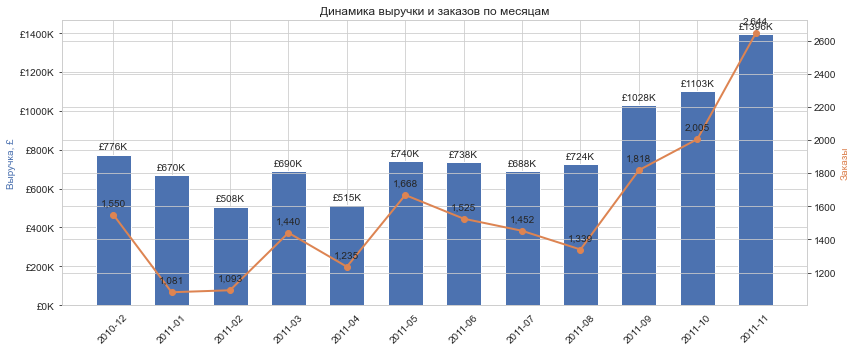

In [17]:
# Визуализация 
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt, matplotlib.ticker as mticker

fig, ax1 = plt.subplots(figsize=(12,5))
months = monthly['Month'].astype(str)

# Столбцы: выручка
bars = ax1.bar(months, monthly['Revenue'], color='#4C72B0', width=0.6)
ax1.bar_label(bars, labels=[f'£{v/1000:.0f}K' for v in monthly['Revenue']], padding=3)
ax1.set_ylabel('Выручка, £', color='#4C72B0')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'£{x/1000:.0f}K'))
ax1.tick_params(axis='x', rotation=45)

# Линия: заказы
ax2 = ax1.twinx()
ax2.plot(months, monthly['Orders'], color='#DD8452', marker='o', linewidth=2)
for x, y in zip(months, monthly['Orders']):
    ax2.annotate(f'{y:,}', (x,y), textcoords='offset points', xytext=(0,9), ha='center', fontsize=10)
ax2.set_ylabel('Заказы', color='#DD8452')

plt.title('Динамика выручки и заказов по месяцам')
fig.tight_layout()
plt.show()

1. Ярко выраженная сезонность:

Пик — ноябрь 2011 (выручка £1.39 млн, 2 644 заказа). Это подготовка к Рождеству.

Дно — февраль 2011 (выручка £508 тыс., 1 093 заказа). Постпраздничный спад.

Чёткий тренд на рост с сентября по ноябрь.

2. Аномалия января 2011:

В январе самое низкое количество заказов (1 081), но самый высокий средний чек (£620).

Это значит, что в январе было мало заказов, но они были очень крупными (оптовые закупки). Это подтверждает нашу гипотезу о наличии B2B-клиентов, которые закупаются большими партиями после праздников.

3. Стабильность среднего чека:

В остальные месяцы чек колеблется в районе £450–£550. Это здоровая розничная картина.

## 5. ABC-анализ

- Считаем выручку по каждому SKU, сортируем, накапливаем долю.  
Нужно проверить, насколько выручка сконцентрирована на малой части ассортимента.  
Это основа для ABC-анализа: если 20% товаров дают 80% выручки — принцип Парето работает.  

In [18]:
# агрегация строго по StockCode + каноническое Description

canonical_desc = (
    df_sales.groupby('StockCode')['Description']
    .agg(lambda x: x.value_counts().index[0])
    .reset_index()
    .rename(columns={'Description': 'Description_Canonical'})
)

# Основной агрегат по SKU с Order_Count 
sku_revenue = df_sales.groupby('StockCode').agg(
    Total_Revenue=('Revenue', 'sum'),
    Total_Quantity=('Quantity', 'sum'),
    Order_Count=('Invoice', 'nunique')
).reset_index()

# Присоединяем каноническое описание
sku_revenue = sku_revenue.merge(canonical_desc, on='StockCode', how='left')

# Сортировка и накопленная доля
sku_revenue = sku_revenue.sort_values('Total_Revenue', ascending=False).reset_index(drop=True)
sku_revenue['Revenue_Share']    = sku_revenue['Total_Revenue'] / total_revenue
sku_revenue['Cumulative_Share'] = sku_revenue['Revenue_Share'].cumsum()

n_sku_rows = len(sku_revenue)   # = n_unique_stockcodes
print(f"Уникальных SKU: {n_sku_rows}")


Уникальных SKU: 3897


- Присваиваем категории на основе накопленной доли (Cumulative_Share).   
 Классическая схема 80/15/5.  
A: до 80% выручки  
B: от 80% до 95%  
C: от 95% до 100%  
Это стандартный отраслевой подход для приоритизации управления запасами.  

- Считаем, сколько SKU, выручки и единиц товара приходится на каждую группу.
Это агрегированный результат, который показывает бизнесу масштаб каждой группы.

In [19]:
# Присвоение ABC
def assign_abc(cum_share):
    if cum_share <= 0.80:   return 'A'
    elif cum_share <= 0.95: return 'B'
    else:                   return 'C'

sku_revenue['ABC_Category'] = sku_revenue['Cumulative_Share'].apply(assign_abc)

abc_summary = sku_revenue.groupby('ABC_Category').agg(
    SKU_Count=('StockCode', 'count'),
    Total_Revenue=('Total_Revenue', 'sum'),
    Total_Quantity=('Total_Quantity', 'sum')
).reset_index()

abc_summary['SKU_Share_%']     = (abc_summary['SKU_Count'] / n_sku_rows * 100).round(1)
abc_summary['Revenue_Share_%'] = (abc_summary['Total_Revenue'] / total_revenue * 100).round(1)

print("\nСВОДНАЯ ТАБЛИЦА ABC:")
print(abc_summary.to_string(index=False))


СВОДНАЯ ТАБЛИЦА ABC:
ABC_Category  SKU_Count  Total_Revenue  Total_Quantity  SKU_Share_%  Revenue_Share_%
           A        832     7660616.36         3544370         21.3             80.0
           B        976     1436415.23         1196841         25.0             15.0
           C       2089      479213.55          479099         53.6              5.0


## 5.1 Визуализация: Кривая Парето

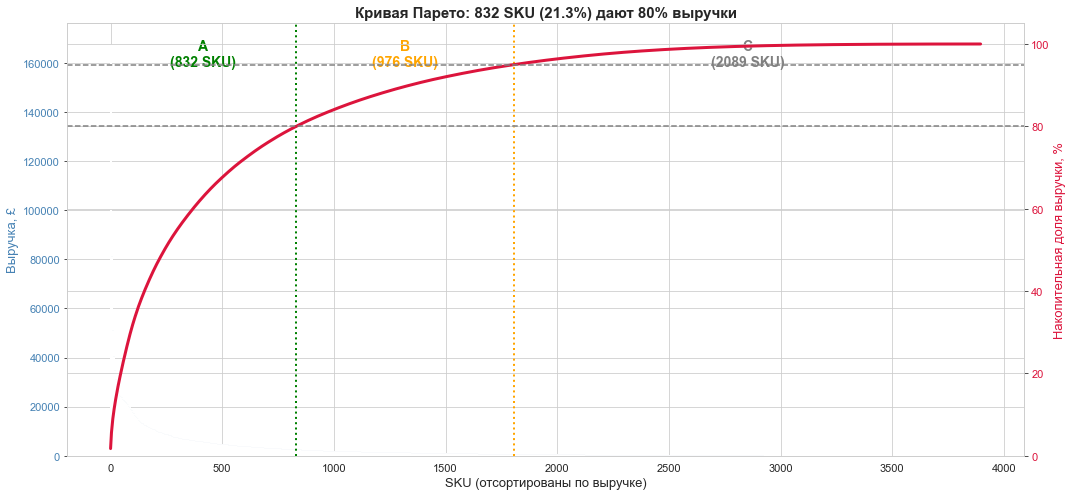

In [20]:
# Строим график Парето
fig, ax1 = plt.subplots(figsize=(15, 7))

# Столбики — выручка SKU по убыванию
ax1.bar(range(len(sku_revenue)), sku_revenue['Total_Revenue'],
        color='steelblue', width=1.0)
ax1.set_xlabel('SKU (отсортированы по выручке)', fontsize=13)
ax1.set_ylabel('Выручка, £', color='steelblue', fontsize=13)
ax1.tick_params(axis='y', labelcolor='steelblue', labelsize=11)
ax1.tick_params(axis='x', labelsize=11)

# Линия — накопительная доля (в %)
ax2 = ax1.twinx()
ax2.plot(range(len(sku_revenue)),
         sku_revenue['Cumulative_Share'] * 100,
         color='crimson', linewidth=3)
ax2.axhline(80, color='grey', linestyle='--', linewidth=1.5)
ax2.axhline(95, color='grey', linestyle='--', linewidth=1.5)
ax2.set_ylabel('Накопительная доля выручки, %', color='crimson', fontsize=13)
ax2.tick_params(axis='y', labelcolor='crimson', labelsize=11)
ax2.set_ylim(0, 105)

# Вертикальные границы зон A / B / C
n_a = (sku_revenue['ABC_Category'] == 'A').sum()
n_b = (sku_revenue['ABC_Category'] == 'B').sum()
n_c = (sku_revenue['ABC_Category'] == 'C').sum()

ax1.axvline(n_a, color='green', linestyle=':', linewidth=2)
ax1.axvline(n_a + n_b, color='orange', linestyle=':', linewidth=2)

# Подписи зон
ax1.text(n_a / 2, ax1.get_ylim()[1] * 0.9, f'A\n({n_a} SKU)',
         ha='center', fontsize=14, color='green', fontweight='bold')
ax1.text(n_a + n_b / 2, ax1.get_ylim()[1] * 0.9, f'B\n({n_b} SKU)',
         ha='center', fontsize=14, color='orange', fontweight='bold')
ax1.text(n_a + n_b + n_c / 2, ax1.get_ylim()[1] * 0.9, f'C\n({n_c} SKU)',
         ha='center', fontsize=14, color='grey', fontweight='bold')

# Заголовок с ключевыми цифрами
plt.title(
    f'Кривая Парето: {n_a} SKU ({n_a/len(sku_revenue)*100:.1f}%) дают 80% выручки',
    fontsize=15, fontweight='bold'
)
plt.tight_layout()
plt.show()

**Принцип Парето соблюден: 21.3% ассортимента (832 SKU) приносят 80% выручки.**

Категория А: 21.3% SKU дают 80,0% выручки  
Категория В: 25,% SKU дают 15,0% выручки  
Категория С: 53,6% SKU дают всего 5,0% выручки.  

Границы: A — накопительная доля до 80% (832 SKU); B — от 80% до 95% (976 SKU); C — свыше 95% (2 089 SKU).  
Категория C — не «плохой товар», а низкий вклад в выручку. Решение об удалении возможно только после XYZ-анализа и учёта роли товара в корзине.  


## 6. XYZ-анализ

ABC показал сколько денег приносит товар. XYZ покажет насколько стабильно он продается по месяцам.  
Для каждого StockCode сформируем временной ряд количества проданных единиц по месяцам. Затем рассчитаем среднее месячное количество, стандартное отклонение и коэффициент вариации CV = std / mean.  
В качестве базовых порогов используем X: CV ≤ 0,5; Y: 0,5 < CV ≤ 1; Z: CV > 1

In [21]:
# 1. Сводная таблица: SKU x Месяц по Quantity (полный календарь, 12 месяцев)
pivot_qty = df_sales.pivot_table(
    index='StockCode',
    columns='Month',
    values='Quantity',
    aggfunc='sum'
).fillna(0)

print(f"Количество месяцев в ряду: {pivot_qty.shape[1]} (должно быть 12)")
print(f"Количество SKU: {pivot_qty.shape[0]}")

Количество месяцев в ряду: 12 (должно быть 12)
Количество SKU: 3897


In [22]:
# 2. Среднее месячное количество и стандартное отклонение
mean_qty = pivot_qty.mean(axis=1)
std_qty = pivot_qty.std(axis=1)

# 3. Коэффициент вариации CV = std / mean
# Если mean = 0 (товар вообще не продавался), CV неопределён → помечаем как NaN
cv = std_qty / mean_qty.replace(0, np.nan)

# 4. Классификация XYZ по заданным порогам
def assign_xyz(cv_val):
    if pd.isna(cv_val):
        return 'Z'  # нет продаж или среднее = 0 → нерегулярный
    elif cv_val <= 0.5:
        return 'X'
    elif cv_val <= 1.0:
        return 'Y'
    else:
        return 'Z'

xyz_data = pd.DataFrame({
    'Mean_Qty': mean_qty,
    'Std_Qty': std_qty,
    'CV': cv
}).reset_index()

xyz_data['XYZ_Category'] = xyz_data['CV'].apply(assign_xyz)
xyz_data['Zero_Months'] = (pivot_qty == 0).sum(axis=1).values
xyz_data['Active_Months'] = 12 - xyz_data['Zero_Months']

print("\nРАСПРЕДЕЛЕНИЕ SKU ПО XYZ:")
print(xyz_data['XYZ_Category'].value_counts().sort_index())




РАСПРЕДЕЛЕНИЕ SKU ПО XYZ:
X     325
Y    1065
Z    2507
Name: XYZ_Category, dtype: int64


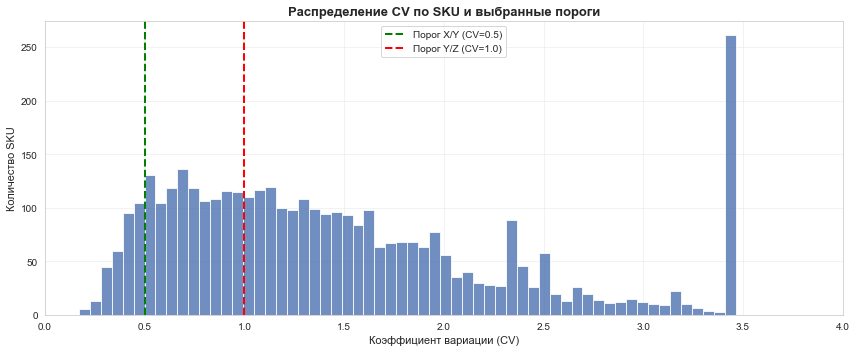


АНАЛИЗ ОСОБЫХ СЛУЧАЕВ

1. Товары с 6+ нулевыми месяцами: 1385 SKU
2. Товары со средним продаж < 1 ед/мес: 459 SKU
3. Товары с CV > 1, но активные 6+ месяцев (вероятно сезонные): 1397 SKU

Таблица xyz_data готова к объединению с ABC.
  StockCode    Mean_Qty     Std_Qty        CV XYZ_Category  Zero_Months  \
0     10002   71.666667  119.154852  1.662626            Z            7   
1     10080   25.250000   33.092501  1.310594            Z            5   
2     10120   15.166667   15.561218  1.026014            Z            3   
3     10125  105.750000   70.728836  0.668831            Y            1   
4     10133  238.000000  295.301079  1.240761            Z            2   

   Active_Months  
0              5  
1              7  
2              9  
3             11  
4             10  


In [23]:
# 5. Визуализация распределения CV (обоснование порогов)
fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(xyz_data['CV'].dropna(), bins=60, color='#4C72B0', alpha=0.8, edgecolor='white')
ax.axvline(0.5, color='green', linestyle='--', linewidth=2, label='Порог X/Y (CV=0.5)')
ax.axvline(1.0, color='red', linestyle='--', linewidth=2, label='Порог Y/Z (CV=1.0)')
ax.set_xlabel('Коэффициент вариации (CV)', fontsize=11)
ax.set_ylabel('Количество SKU', fontsize=11)
ax.set_title('Распределение CV по SKU и выбранные пороги', fontsize=13, fontweight='bold')
ax.set_xlim(0, 4)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 6. Анализ особых случаев
print("\n" + "=" * 60)
print("АНАЛИЗ ОСОБЫХ СЛУЧАЕВ")
print("=" * 60)

# 6.1. Поздно появившиеся / редкие товары (6+ нулевых месяцев)
late = xyz_data[xyz_data['Zero_Months'] >= 6]
print(f"\n1. Товары с 6+ нулевыми месяцами: {len(late)} SKU")

# 6.2. Очень низкое среднее (< 1 ед/мес)
low_mean = xyz_data[xyz_data['Mean_Qty'] < 1]
print(f"2. Товары со средним продаж < 1 ед/мес: {len(low_mean)} SKU")

# 6.3. Товары с CV > 1, но активные (сезонность, не смерть)
seasonal = xyz_data[(xyz_data['CV'] > 1) & (xyz_data['Active_Months'] >= 6)]
print(f"3. Товары с CV > 1, но активные 6+ месяцев (вероятно сезонные): {len(seasonal)} SKU")

# 7. Сохраняем результат для объединения с ABC
# xyz_data теперь содержит: StockCode, Mean_Qty, Std_Qty, CV, XYZ_Category, Zero_Months, Active_Months
print("\nТаблица xyz_data готова к объединению с ABC.")
print(xyz_data.head())

# 7. Объединенная матрица ABC/XYZ

Объединяем ABC-категории (по выручке) и XYZ-категории (по стабильности).  
Это финальная сегментация. Мы получаем 9 групп (AX, AY, AZ, BX, BY, BZ, CX, CY, CZ).  
 Затем агрегируем бизнес-метрики по каждой группе.
Это финальный срез ассортимента — он показывает не просто "буквы", 
а реальные деньги, клиентов и предсказуемость спроса по каждой группе.

In [24]:
# 1. Добавляем XYZ-метрики к sku_revenue
matrix_sku = sku_revenue.merge(
    xyz_data[['StockCode','Mean_Qty','Std_Qty','CV','XYZ_Category',
              'Zero_Months','Active_Months']],
    on='StockCode',
    how='left'
)

# 2. Добавляем количество уникальных клиентов по SKU
cust = (
    df_sales.groupby('StockCode')['Customer ID']
    .nunique()
    .reset_index(name='Customer_Count')
)

# 3. Добавляем первую и последнюю продажу
dates = (
    df_sales.groupby('StockCode')['InvoiceDate']
    .agg(First_Sale='min', Last_Sale='max')
    .reset_index()
)

matrix_sku = matrix_sku.merge(cust, on='StockCode', how='left')
matrix_sku = matrix_sku.merge(dates, on='StockCode', how='left')

# 4. Объединённая группа ABC/XYZ
matrix_sku['ABC_XYZ'] = matrix_sku['ABC_Category'] + matrix_sku['XYZ_Category']

# 5. Сезонность: доля самого пикового месяца
peak_share = (
    pivot_qty.max(axis=1) / pivot_qty.sum(axis=1)
).reset_index(name='Peak_Month_Share')

peak_month = (
    pivot_qty.idxmax(axis=1).astype(str)
    .reset_index(name='Peak_Month')
)

matrix_sku = matrix_sku.merge(peak_share, on='StockCode', how='left')
matrix_sku = matrix_sku.merge(peak_month, on='StockCode', how='left')

# 6. Флаги: новый товар и явная сезонность
matrix_sku['New_Flag'] = matrix_sku['First_Sale'] >= pd.Timestamp('2011-08-01')
matrix_sku['Seasonal_Flag'] = (
    (matrix_sku['Peak_Month_Share'] >= 0.5) &
    (matrix_sku['Total_Quantity'] >= 50)
)

# Создаё агрегированную matrix 


sales_group = df_sales.merge(
    matrix_sku[['StockCode','ABC_XYZ']],
    on='StockCode',
    how='left'
)

matrix = (
    sales_group.groupby('ABC_XYZ')
    .agg(
        SKU_Count=('StockCode','nunique'),
        Total_Revenue=('Revenue','sum'),
        Total_Quantity=('Quantity','sum'),
        Order_Count=('Invoice','nunique'),
        Customer_Count=('Customer ID','nunique')
    )
    .reset_index()
)

avg_active = (
    matrix_sku.groupby('ABC_XYZ')['Active_Months']
    .mean()
    .reset_index(name='Avg_Active_Months')
)

matrix = matrix.merge(avg_active, on='ABC_XYZ', how='left')

matrix['SKU_Share_%'] = matrix['SKU_Count'] / matrix['SKU_Count'].sum() * 100
matrix['Revenue_Share_%'] = matrix['Total_Revenue'] / matrix['Total_Revenue'].sum() * 100
matrix['Avg_Price'] = matrix['Total_Revenue'] / matrix['Total_Quantity']

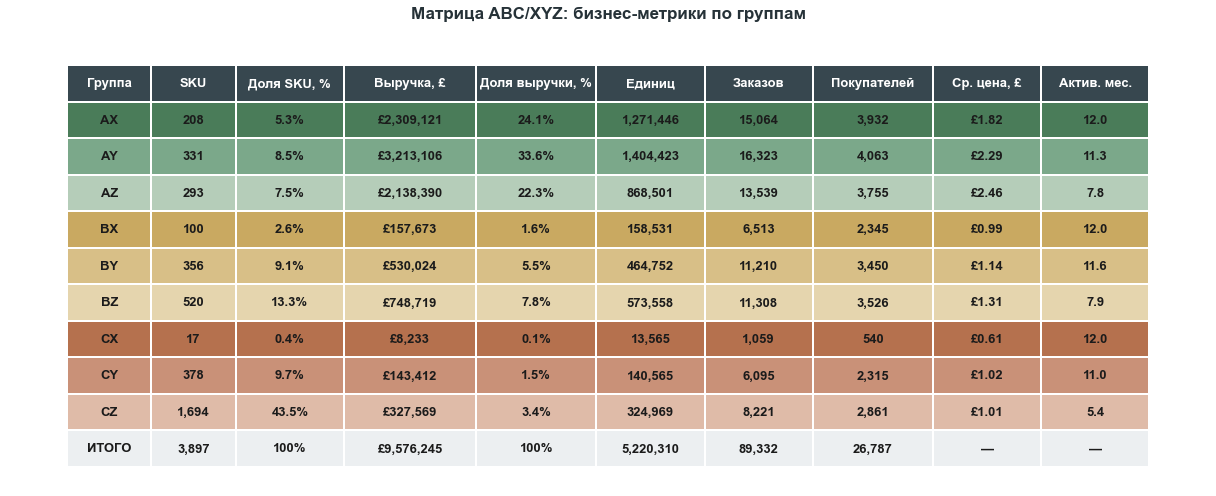

In [25]:
# ---Таблица
# A — спокойный зелёный, B — приглушённый песочный, C — мягкий терракотовый
color_map = {
    'AX': '#4A7C59', 'AY': '#7BA88A', 'AZ': '#B5CDB9',   # A: спокойный зелёный
    'BX': '#C9A961', 'BY': '#D8BF87', 'BZ': '#E5D5AE',   # B: песочный
    'CX': '#B5714E', 'CY': '#C99178', 'CZ': '#DFBBA8'    # C: терракотовый
}

order = ['AX', 'AY', 'AZ', 'BX', 'BY', 'BZ', 'CX', 'CY', 'CZ']
matrix_viz = matrix.set_index('ABC_XYZ').reindex(order).fillna(0).reset_index()

# ==========================================
fig, ax = plt.subplots(figsize=(17, 7))
ax.axis('off')

columns = ['Группа', 'SKU', 'Доля SKU, %', 'Выручка, £', 'Доля выручки, %',
           'Единиц', 'Заказов', 'Покупателей', 'Ср. цена, £', 'Актив. мес.']

cell_text = []
for _, row in matrix_viz.iterrows():
    cell_text.append([
        row['ABC_XYZ'],
        f"{int(row['SKU_Count']):,}",
        f"{row['SKU_Share_%']:.1f}%",
        f"£{row['Total_Revenue']:,.0f}",
        f"{row['Revenue_Share_%']:.1f}%",
        f"{int(row['Total_Quantity']):,}",
        f"{int(row['Order_Count']):,}",
        f"{int(row['Customer_Count']):,}",
        f"£{row['Avg_Price']:.2f}",
        f"{row['Avg_Active_Months']:.1f}"
    ])

# Итоговая строка
cell_text.append([
    'ИТОГО',
    f"{int(matrix_viz['SKU_Count'].sum()):,}",
    '100%',
    f"£{matrix_viz['Total_Revenue'].sum():,.0f}",
    '100%',
    f"{int(matrix_viz['Total_Quantity'].sum()):,}",
    f"{int(matrix_viz['Order_Count'].sum()):,}",
    f"{int(matrix_viz['Customer_Count'].sum()):,}",
    '—',
    '—'
])

table = ax.table(
    cellText=cell_text,
    colLabels=columns,
    cellLoc='center',
    loc='center',
    colWidths=[0.07, 0.07, 0.09, 0.11, 0.10, 0.09, 0.09, 0.10, 0.09, 0.09]
)

table.auto_set_font_size(False)
table.set_fontsize(13)   
table.scale(1, 2.6)      

# Стилизация: пастельные строки по группам
for i, row in matrix_viz.iterrows():
    group = row['ABC_XYZ']
    color = color_map[group]
    for j in range(len(columns)):
        cell = table[(i + 1, j)]
        cell.set_facecolor(color)
        # Первая колонка (название группы) — тёмный текст, остальные — тоже тёмный для контраста
        cell.set_text_props(color='#1B1B1B', fontweight='bold', fontsize=13)
        cell.set_edgecolor('#FFFFFF')
        cell.set_linewidth(2)

# Заголовок таблицы — спокойный тёмно-серый
for j in range(len(columns)):
    cell = table[(0, j)]
    cell.set_facecolor('#37474F')
    cell.set_text_props(color='white', fontweight='bold', fontsize=13)
    cell.set_edgecolor('#FFFFFF')
    cell.set_linewidth(2)

# Итоговая строка
last_row = len(cell_text)
for j in range(len(columns)):
    cell = table[(last_row, j)]
    cell.set_facecolor('#ECEFF1')
    cell.set_text_props(color='#1B1B1B', fontweight='bold', fontsize=13)
    cell.set_edgecolor('#FFFFFF')
    cell.set_linewidth(2)

ax.set_title('Матрица ABC/XYZ: бизнес-метрики по группам',
             fontsize=17, fontweight='bold', pad=25, color='#263238')

plt.tight_layout()
plt.show()

**A: 832 SKU (21.3%) → 80.0% выручки**   
AX — «рабочие лошадки»: продаются каждый месяц без исключения (12.0 мес.), средний чек £3.21. Дефицит недопустим.  
AY — крупнейшая группа по выручке (33.6%). Спрос почти стабилен (11.3 мес.), но с колебаниями. Требует сезонного планирования.  
AZ — сезонные товары (7.8 мес., значит ~4 месяца простоя). Дают 22.3% выручки — сокращать категорически нельзя, но и держать запас круглый год расточительно.  
Риск: группа A — это ровно 80% выручки на 21% ассортимента. Любая ошибка в планировании этих товаров наносит непропорционально большой ущерб.  

**B: 976 SKU (25.0%) → 15.0% выручки**   
BX мало (100 SKU) — стабильные, но малозначимые. Управление стандартное.    
BZ (520 SKU, 7.8 мес.) — самая проблемная группа в B. Каждый SKU в среднем продаётся только 8 месяцев из 12, но при этом в B, а не в C. Это «серая зона»: они ещё приносят деньги, но уже нестабильны. Именно здесь стоит искать кандидатов на перевод в модель «под заказ».  

**C: 2 089 SKU (53.6%) → 5.0% выручки**    
CX — аномально мало (17 SKU). Стабильные, но мизерные. Скорее всего, сопутствующие товары (батарейки, упаковка). Проверить индивидуально, но массово не сокращать.  
CY — умеренно вариативные «малыши» (11 мес., 1.5% выручки). Кандидаты на модель «заказ под клиента».  
CZ — это и есть главная цель проекта: 1 694 SKU (43.5% всего ассортимента!) дают лишь 3.4% выручки. Продаются в среднем 5.4 месяца из 12 — то есть больше половины года лежат мёртвым грузом на складе. Средняя цена £3.38 — дешёвая мелочёвка.  

1. Потенциал сокращения сосредоточен в одной группе    
CZ = 43.5% ассортимента = 3.4% выручки. Это классический балласт: огромный объём SKU при ничтожном вкладе. Даже если сократить половину группы CZ, потеря выручки будет в районе 1.5–1.7%.   
 
 
2. ABC и XYZ не дублируют, а дополняют друг друга  
Товар может быть дорогим (A), но нестабильным (Z) — это AZ, который нельзя удалять, только грамотно управлять запасом. Или дешёвым (C), но стабильным (X) — это CX, который лучше оставить как сопутствующий.
Именно пересечение групп даёт бизнес-смысл, а не сами буквы  


3. Три разные стратегии управления  
A    (AX/AY/AZ)	- Локомотивы: 	Всегда в наличии, автоматический контроль дефицита, защита от вывода  
B    (BX/BY/BZ)	- Средний класс: Стандартный запас. BZ — пересмотреть на модель «под заказ»  
C    (CX/CY/CZ)	- Балласт:	CX оставить, CY — под заказ, CZ — главный пул для сокращения  

# 8. Интерпретация и стратегия управления

In [26]:
# Добавляем колонки для стратегического анализа
strategy = matrix.copy()

strategy['Rev_per_SKU']     = strategy['Total_Revenue'] / strategy['SKU_Count']
strategy['Orders_per_SKU']  = strategy['Order_Count'] / strategy['SKU_Count']
strategy['Customers_per_SKU'] = strategy['Customer_Count'] / strategy['SKU_Count']
strategy['Rev_minus_SKU']   = strategy['Revenue_Share_%'] - strategy['SKU_Share_%']

strategy = strategy[[
    'ABC_XYZ', 'SKU_Count', 'SKU_Share_%', 'Total_Revenue', 'Revenue_Share_%',
    'Rev_per_SKU', 'Orders_per_SKU', 'Customers_per_SKU',
    'Avg_Active_Months', 'Avg_Price', 'Rev_minus_SKU'
]]

# Сортируем по доле выручки
strategy = strategy.sort_values('Revenue_Share_%', ascending=False)

# Формируем читаемый вывод с форматированием вручную
print("=" * 115)
print("СТРАТЕГИЧЕСКАЯ ТАБЛИЦА: ДИСБАЛАНС SKU И ВЫРУЧКИ ПО ГРУППАМ ABC/XYZ")
print("=" * 115)
print(f"{'Группа':<8}{'SKU':>7}{'SKU,%':>9}{'Выручка,£':>14}"
      f"{'Выр,%':>8}{'£/SKU':>10}{'Заказы/SKU':>12}"
      f"{'Клиенты/SKU':>13}{'Мес.акт.':>10}{'Ср.цена':>10}{'Δ(Выр−SKU)':>13}")
print("-" * 115)

for _, r in strategy.iterrows():
    print(f"{r['ABC_XYZ']:<8}"
          f"{int(r['SKU_Count']):>7,}"
          f"{r['SKU_Share_%']:>9.1f}"
          f"{r['Total_Revenue']:>14,.0f}"
          f"{r['Revenue_Share_%']:>8.1f}"
          f"{r['Rev_per_SKU']:>10,.0f}"
          f"{r['Orders_per_SKU']:>12.1f}"
          f"{r['Customers_per_SKU']:>13.1f}"
          f"{r['Avg_Active_Months']:>10.1f}"
          f"{r['Avg_Price']:>10.2f}"
          f"{r['Rev_minus_SKU']:>+13.1f}")

print("-" * 115)
print(f"{'ИТОГО':<8}"
      f"{int(strategy['SKU_Count'].sum()):>7,}"
      f"{strategy['SKU_Share_%'].sum():>9.1f}"
      f"{strategy['Total_Revenue'].sum():>14,.0f}"
      f"{strategy['Revenue_Share_%'].sum():>8.1f}")
print("=" * 115)

print("\n📖 Как читать таблицу:")
print("  • SKU,%          — доля группы в общем числе товаров")
print("  • Выр,%          — доля группы в общей выручке")
print("  • £/SKU          — сколько выручки приносит 1 товар группы")
print("  • Заказы/SKU     — как часто товар группы встречается в заказах")
print("  • Клиенты/SKU    — сколько разных покупателей берут товар группы")
print("  • Мес.акт.       — сколько месяцев в году товар реально продаётся")
print("  • Δ(Выр−SKU) > 0 — группа «недооценена» (мало SKU, много денег)")
print("  • Δ(Выр−SKU) < 0 — группа «перегружена» (много SKU, мало денег)")

СТРАТЕГИЧЕСКАЯ ТАБЛИЦА: ДИСБАЛАНС SKU И ВЫРУЧКИ ПО ГРУППАМ ABC/XYZ
Группа      SKU    SKU,%     Выручка,£   Выр,%     £/SKU  Заказы/SKU  Клиенты/SKU  Мес.акт.   Ср.цена   Δ(Выр−SKU)
-------------------------------------------------------------------------------------------------------------------
AY          331      8.5     3,213,106    33.6     9,707        49.3         12.3      11.3      2.29        +25.1
AX          208      5.3     2,309,121    24.1    11,102        72.4         18.9      12.0      1.82        +18.8
AZ          293      7.5     2,138,390    22.3     7,298        46.2         12.8       7.8      2.46        +14.8
BZ          520     13.3       748,719     7.8     1,440        21.7          6.8       7.9      1.31         -5.5
BY          356      9.1       530,024     5.5     1,489        31.5          9.7      11.6      1.14         -3.6
CZ        1,694     43.5       327,569     3.4       193         4.9          1.7       5.4      1.01        -40.0
BX          

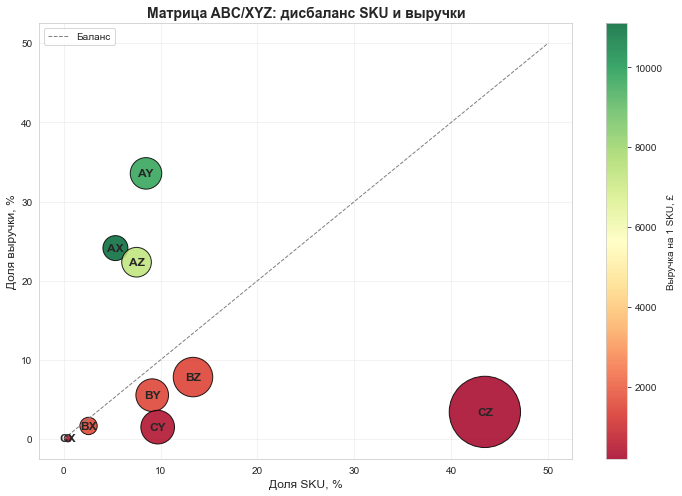

In [27]:
# Визуализация: дисбаланс SKU и выручки
fig, ax = plt.subplots(figsize=(10, 7))

# Диагональ «SKU = выручка»
ax.plot([0, 50], [0, 50], color='grey', linestyle='--', linewidth=1, label='Баланс')

# Точки групп: размер = число SKU, цвет = выручка на 1 SKU
scatter = ax.scatter(
    strategy['SKU_Share_%'], strategy['Revenue_Share_%'],
    s=strategy['SKU_Count'] * 3,
    c=strategy['Rev_per_SKU'],
    cmap='RdYlGn', edgecolor='black', alpha=0.85
)

# Подписи групп
for _, row in strategy.iterrows():
    ax.annotate(row['ABC_XYZ'],
                (row['SKU_Share_%'], row['Revenue_Share_%']),
                fontsize=12, ha='center', va='center', fontweight='bold')

ax.set_xlabel('Доля SKU, %', fontsize=12)
ax.set_ylabel('Доля выручки, %', fontsize=12)
ax.set_title('Матрица ABC/XYZ: дисбаланс SKU и выручки', fontsize=14, fontweight='bold')
ax.grid(alpha=0.3)
ax.legend()

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Выручка на 1 SKU, £')

plt.tight_layout()
plt.show()

**Стратегия по каждой группе**

🟢 AX — 208 SKU (5.3% ассортимента) → 24.1% выручки
Приоритет №1. Всегда в наличии.
Продаётся все 12 месяцев без простоев, £11 102 с SKU — максимальная отдача в ассортименте.
Запас: автоматическое пополнение, страховой запас минимальный (спрос стабилен).
Уровень сервиса: 99%. Любой дефицит = прямая потеря денег.
Контроль: еженедельный.

🟢 AY — 331 SKU (8.5%) → 33.6% выручки
Запас есть всегда, но с сезонной надбавкой.
Активны 11.3 мес., но с колебаниями объёмов. Крупнейшая группа по выручке.
Запас: буфер + сезонное планирование по месяцам.
Уровень сервиса: 97%.
Контроль: еженедельный.

🟢 AZ — 293 SKU (7.5%) → 22.3% выручки
Не сокращать. Отдельный сезонный бюджет.
Активны только 7.8 мес. — почти 4 месяца простоя, но дают 22% выручки.
Запас: закупка под сезон, не круглый год. Осторожный объём.
Уровень сервиса: 95% в сезон, ниже вне сезона.
Контроль: ежемесячный + предсезонный пересмотр.

🟡 BX — 100 SKU (2.6%) → 1.6% выручки
Стандартное управление.
Стабильные (12 мес.), но малозначимые.
Запас: автопополнение, стандартные параметры.
Контроль: ежемесячно.

🟡 BY — 356 SKU (9.1%) → 5.5% выручки
Умеренно осторожное управление.
Активны 11.6 мес., но средняя цена низкая (£2.82), отдача слабая.
Запас: оптимизировать точку заказа.
Контроль: ежемесячно.

🟡 BZ — 520 SKU (13.3%) → 7.8% выручки
Кандидат на пилот «под заказ».
Активны только 7.9 мес. — 4 месяца лежат мёртвым грузом. £1 440 с SKU против £11 102 у AX.
Запас: ограниченный; пилот — перевести 20% SKU на модель «под заказ».
Уровень сервиса: 85%.
Контроль: ежеквартально.

🔴 CX — 17 SKU (0.4%) → 0.1% выручки
Не удалять. Проверить роль в корзине вручную.
Стабильные (12 мес.), но выручка мизерная. Скорее всего, сопутствующие товары (упаковка, батарейки).
Запас: минимальный, ручной.
Контроль: раз в квартал.

🔴 CY — 378 SKU (9.7%) → 1.5% выручки
Пилот «под заказ», мониторинг 6 месяцев.
£379 с SKU — в 30 раз меньше, чем у AX. Активны 11 мес., но объёмы ничтожные.
Запас: под заказ или крайне низкий.
Уровень сервиса: 75%.
Контроль: ежеквартально.

🔴 CZ — 1 694 SKU (43.5%) → 3.4% выручки
Главный пул сокращения. НЕ автоматический список удаления.
43.5% ассортимента дают 3.4% выручки. Δ(Выр−SKU) = −40 п.п. Активны 5.4 мес. из 12.
Товар берут всего 12 клиентов/год на один SKU — «прицепного» эффекта нет.
Запас: только под конкретный заказ.
Уровень сервиса: 70%.
Контроль: раз в полгода.
Действие: поэтапный вывод партиями по ABC-тесту с мониторингом потерь. Оценка: удаление 50% CZ ≈ −1.7% выручки, освобождение ~850 складских позиций.

# 9. Формирование списка кандидатов на сокращение

In [28]:
cand = matrix_sku.copy()

# --- Дополнительные метрики ---
cand['Avg_Price'] = cand['Total_Revenue'] / cand['Total_Quantity']
cand['ActiveMonths'] = cand['Active_Months']
cand['Customer_Freq'] = cand['Customer_Count']

# Доля выручки товара
total_rev = cand['Total_Revenue'].sum()
cand['Rev_share_%'] = cand['Total_Revenue'] / total_rev * 100

cand.head()

,StockCode,Total_Revenue,Total_Quantity,Order_Count,Description_Canonical,Revenue_Share,Cumulative_Share,ABC_Category,Mean_Qty,Std_Qty,...,Last_Sale,ABC_XYZ,Peak_Month_Share,Peak_Month,New_Flag,Seasonal_Flag,Avg_Price,ActiveMonths,Customer_Freq,Rev_share_%
0,22423,167671.71,13367,1919,REGENCY CAKESTAND 3 TIER,0.017509,0.017509,A,1113.916667,358.413539,...,2011-11-29 16:47:00,AX,0.155383,2010-12,False,False,12.543705,12,870,1.750913
1,85123A,101421.29,36515,2121,WHITE HANGING HEART T-LIGHT HOLDER,0.010591,0.028100,A,3042.916667,1282.204952,...,2011-11-29 16:47:00,AX,0.151362,2011-01,False,False,2.777524,12,845,1.059092
2,47566,98380.14,18128,1654,PARTY BUNTING,0.010273,0.038373,A,1510.666667,991.229295,...,2011-11-29 14:42:00,AY,0.196105,2011-05,False,False,5.426972,12,704,1.027335
3,85099B,91519.59,47077,2024,JUMBO BAG RED RETROSPOT,0.009557,0.047930,A,3923.083333,1274.366328,...,2011-11-29 16:47:00,AX,0.121482,2011-11,False,False,1.944040,12,622,0.955694
4,23166,81382.04,77765,230,MEDIUM CERAMIC TOP STORAGE JAR,0.008498,0.056429,A,6480.416667,21332.800913,...,2011-11-29 17:52:00,AZ,0.954350,2011-01,False,True,1.046512,8,134,0.849832


In [29]:
# # На всякий случай убеждаемся, что Customer_Count есть
# if 'Customer_Count' not in matrix_sku.columns:
#     cust = (
#         df_sales.groupby('StockCode')['Customer ID']
#         .nunique().reset_index(name='Customer_Count')
#     )
#     matrix_sku = matrix_sku.merge(cust, on='StockCode', how='left')
#     cand = matrix_sku.copy()
#     cand['Avg_Price'] = cand['Total_Revenue'] / cand['Total_Quantity'].replace(0, np.nan)
#     cand['ActiveMonths'] = cand['Active_Months']
#     cand['Customer_Freq'] = cand['Customer_Count']
#     cand['Rev_share_%'] = cand['Total_Revenue'] / cand['Total_Revenue'].sum() * 100

In [30]:
# Отбор кандидатов
# --- Пул: CZ + BZ ---
cand['pool']          = cand['ABC_XYZ'].isin(['CZ', 'BZ'])
cand['is_low_active'] = cand['ActiveMonths'] < 6
cand['is_low_revenue']= cand['Total_Revenue'] < 1000
cand['is_narrow']     = cand['Customer_Count'] < 50

# Исключаем новые и явно сезонные товары из автоматического вывода
# cand['not_new']       = ~cand['New_Flag']
# cand['not_seasonal']  = ~cand['Seasonal_Flag']

cand['candidate'] = (
    cand['pool'] &
    cand['is_low_active'] &
    cand['is_low_revenue'] &
    cand['is_narrow']
)

n_total = len(cand)
n_cand  = cand['candidate'].sum()
print(f'Всего SKU:              {n_total:,}')
print(f'Кандидатов на сокращение: {n_cand:,} ({n_cand/n_total:.1%})')

cand_rev = cand.loc[cand['candidate'], 'Total_Revenue'].sum()
print(f'Выручка кандидатов: £{cand_rev:,.0f} ({cand_rev/total_rev:.2%} от общей)')

Всего SKU:              3,897
Кандидатов на сокращение: 931 (23.9%)
Выручка кандидатов: £108,885 (1.14% от общей)


In [31]:
# Разбивка кандидатов по группам
cand[cand['candidate']].groupby('ABC_XYZ').agg(
    SKU=('StockCode', 'count'),
    Revenue=('Total_Revenue', 'sum'),
).sort_values('SKU', ascending=False)

,SKU,Revenue
ABC_XYZ,,
CZ,906,87144.48
BZ,25,21740.91


In [32]:
print('Пул (CZ + BZ):                          ', cand['pool'].sum())
print('+ активность < 6 мес:                   ', (cand['pool'] & cand['is_low_active']).sum())
print('+ выручка < £1 000:                     ',
      (cand['pool'] & cand['is_low_active'] & cand['is_low_revenue']).sum())
print('+ покупатели < 50:                      ',
      (cand['pool'] & cand['is_low_active'] & cand['is_low_revenue'] & cand['is_narrow']).sum())
print('+ финал (candidate):                    ', cand['candidate'].sum())

Пул (CZ + BZ):                           2214
+ активность < 6 мес:                    1043
+ выручка < £1 000:                      948
+ покупатели < 50:                       931
+ финал (candidate):                     931


In [33]:
# Таблица кандидатов
cand_table = cand[cand['candidate']].copy()

cand_table = cand_table[[
    'StockCode', 'Description_Canonical', 'ABC_Category', 'XYZ_Category', 'ABC_XYZ',
    'Total_Revenue', 'Rev_share_%', 'Total_Quantity',
    'Order_Count', 'Customer_Count', 'ActiveMonths', 'Avg_Price',
    'First_Sale', 'Last_Sale'
]].rename(columns={
    'Description_Canonical': 'Description',
    'ABC_Category': 'ABC',
    'XYZ_Category': 'XYZ',
    'Total_Revenue': 'Revenue',
    'Total_Quantity': 'Quantity',
    'Order_Count': 'Orders',
    'Customer_Count': 'Customers',
})

cand_table = cand_table.sort_values('Revenue', ascending=False).reset_index(drop=True)

# Рекомендация по каждому SKU
cand_table['Recommendation'] = (
    'Проверить на вывод: CZ/BZ, <6 мес. активности, '
    'выручка < £1 000, узкая клиентская база'
)

cand_table.head(20)

,StockCode,Description,ABC,XYZ,ABC_XYZ,Revenue,Rev_share_%,Quantity,Orders,Customers,ActiveMonths,Avg_Price,First_Sale,Last_Sale,Recommendation
0,22242,5 HOOK HANGER MAGIC TOADSTOOL,B,Z,BZ,994.38,0.010384,640,34,23,3,1.553719,2010-12-01 09:59:00,2011-02-16 10:32:00,"Проверить на вывод: CZ/BZ, <6 мес. активности,..."
1,23544,WALL ART MID CENTURY MODERN,B,Z,BZ,983.13,0.010266,159,16,15,2,6.183208,2011-10-03 13:49:00,2011-11-20 14:07:00,"Проверить на вывод: CZ/BZ, <6 мес. активности,..."
2,85064,CREAM SWEETHEART LETTER RACK,B,Z,BZ,976.25,0.010194,215,30,20,2,4.540698,2010-12-01 14:32:00,2011-01-27 12:40:00,"Проверить на вывод: CZ/BZ, <6 мес. активности,..."
3,23517,EMBROIDERED RIBBON REEL REBECCA,B,Z,BZ,970.36,0.010133,326,60,48,3,2.976564,2011-09-22 12:23:00,2011-11-28 15:31:00,"Проверить на вывод: CZ/BZ, <6 мес. активности,..."
4,23518,EMBROIDERED RIBBON REEL RACHEL,B,Z,BZ,963.07,0.010057,355,43,39,3,2.712873,2011-09-22 14:10:00,2011-11-24 09:21:00,"Проверить на вывод: CZ/BZ, <6 мес. активности,..."
5,23533,WALL ART GARDEN HAVEN,B,Z,BZ,947.64,0.009896,195,30,21,2,4.859692,2011-10-03 11:01:00,2011-11-28 15:31:00,"Проверить на вывод: CZ/BZ, <6 мес. активности,..."
6,21717,EASTER TIN BUCKET,B,Z,BZ,946.93,0.009888,408,41,34,4,2.320907,2010-12-08 14:25:00,2011-03-22 11:05:00,"Проверить на вывод: CZ/BZ, <6 мес. активности,..."
7,23540,WALL ART THE MAGIC FOREST,B,Z,BZ,937.56,0.009790,148,12,7,2,6.334865,2011-10-03 14:34:00,2011-11-25 10:58:00,"Проверить на вывод: CZ/BZ, <6 мес. активности,..."
8,23512,EMBROIDERED RIBBON REEL ROSIE,B,Z,BZ,931.62,0.009728,481,49,41,3,1.936840,2011-09-22 14:10:00,2011-11-28 10:46:00,"Проверить на вывод: CZ/BZ, <6 мес. активности,..."
9,23552,BICYCLE PUNCTURE REPAIR KIT,B,Z,BZ,910.05,0.009503,443,38,35,1,2.054289,2011-11-25 10:58:00,2011-11-29 16:47:00,"Проверить на вывод: CZ/BZ, <6 мес. активности,..."


In [34]:
cand_table.to_excel('candidates_to_review.xlsx', index=False)
print('Сохранено:', len(cand_table), 'SKU → candidates_to_review.xlsx')

Сохранено: 931 SKU → candidates_to_review.xlsx


Логика отбора. В качестве пула для проверки взяты группы CZ и BZ — это товары с низким вкладом в выручку (C) или средним вкладом при сильной вариативности спроса (BZ), которые продаются нестабильно и обслуживают узкую клиентскую базу. Дополнительно наложены три жёстких условия:

активность менее 6 месяцев из 12 — товар отсутствует в продажах минимум половину года;

историческая выручка менее £1 000 — вклад в оборот минимален;

менее 50 уникальных покупателей — узкая клиентская база, отсутствует массовый спрос.

Все три условия должны выполняться одновременно. Это защищает от того, чтобы в список попали сезонные товары с высокой выручкой или редкие позиции, которые покупает большое число клиентов.

Воронка отбора. Из 3 897 SKU исходного ассортимента в пул CZ+BZ попали 2 214 товаров. После фильтра по активности осталось 1 043 SKU, после фильтра по выручке — 948 SKU, а после ограничения по числу покупателей — 931 SKU. То есть каждый следующий критерий отсекал сравнительно небольшую долю, что говорит о согласованности признаков: неактивные товары, как правило, одновременно и низковыручные, и узкие по клиентам.

Итоговые цифры. Кандидатами на вывод признаны 931 SKU — 23,9 % ассортимента. Совокупная историческая выручка этих товаров за период декабрь 2010 — ноябрь 2011 составила £108 885, или 1,14 % от общей выручки магазина.

Структура списка. Подавляющая часть кандидатов — 906 SKU из группы CZ с суммарной выручкой £87 144; оставшиеся 25 SKU относятся к BZ и дают £21 741. Это ожидаемо: BZ — «серая зона» среднего вклада, где товар уже нестабилен, но ещё приносит заметные деньги, поэтому таких позиций в жёстком списке мало.

Ключевой вывод. Дисбаланс между долей ассортимента и долей выручки экстремальный: почти четверть всех товарных позиций формирует чуть больше одного процента оборота. Это означает, что сокращение в пределах списка несёт минимальный риск потери выручки, а освобождаемые складские позиции и упрощение закупок дают понятный операционный эффект. При этом 1,14 % — это историческая доля, а не гарантированный размер будущих потерь: часть спроса может перераспределиться на другие товары, часть вернётся через B2B-клиентов, которые закажут эти SKU отдельно. Поэтому финальное решение по каждому кандидату требует данных о себестоимости, марже, остатках и роли товара в корзине.

# 10. Оценка потенциального эффекта


In [42]:

# Сколько SKU в исходной выборке и сколько предлагается вывести ---
n_total_skus = cand['StockCode'].nunique()
n_cand_skus  = cand_table['StockCode'].nunique()

sku_share_cut = n_cand_skus / n_total_skus * 100

# Историческая выручка кандидатов ---
revenue_total  = cand['Total_Revenue'].sum()
revenue_cut    = cand_table['Revenue'].sum()
rev_share_cut  = revenue_cut / revenue_total * 100

# Дополнительно: единицы, заказы, клиенты по кандидатам ---
cand_skus_set = set(cand_table['StockCode'])
mask_cand = df_sales['StockCode'].isin(cand_skus_set)

units_cut     = df_sales.loc[mask_cand, 'Quantity'].sum()
orders_cut    = df_sales.loc[mask_cand, 'Invoice'].nunique()
customers_cut = df_sales.loc[mask_cand, 'Customer ID'].nunique()

# Бизнес-ориентир 20% ---
target_n = int(round(0.20 * n_total_skus))
diff_n   = n_cand_skus - target_n


print("=" * 65)
print("ЭТАП 8. ОЦЕНКА ПОТЕНЦИАЛЬНОГО ЭФФЕКТА")
print("=" * 65)
print(f"Всего SKU в анализируемой выборке:        {n_total_skus:,}")
print(f"Предложено вывести на проверку:           {n_cand_skus:,}")
print(f"Доля ассортимента:                        {sku_share_cut:.1f}%")
print("-" * 65)
print(f"Историческая выручка кандидатов:          £{revenue_cut:,.0f}")
print(f"Доля в общей выручке:                     {rev_share_cut:.2f}%")
print("-" * 65)
print(f"Проданных единиц кандидатов:              {units_cut:,}")
print(f"Уникальных заказов с кандидатами:         {orders_cut:,}")
print(f"Уникальных клиентов, бравших кандидатов:  {customers_cut:,}")
print("=" * 65)

# 6. Сравнение с бизнес-ориентиром ---
print(f"\nБизнес-ориентир: 20% ассортимента ≈ {target_n} SKU")
if n_cand_skus < target_n:
    print(f"→ Кандидатов меньше ориентира на {abs(diff_n)} SKU.")
    print("  Безопаснее сокращать меньше 20%: дальнейшее расширение списка")
    print("  рискованно без данных о наличии, марже и роли товара в корзине.")
elif n_cand_skus == target_n:
    print("→ Кандидатов ровно столько, сколько заложено в бизнес-ориентире.")
else:
    print(f"→ Кандидатов больше ориентира на {diff_n} SKU.")
    print("  Стоит ужесточить пороги или разбить список на две волны.")

# 7. Ключевое сопоставление ---
print("\n" + "=" * 65)
print("ГЛАВНЫЙ КОЛИЧЕСТВЕННЫЙ ИТОГ")
print("=" * 65)
print(f"{sku_share_cut:.1f}% ассортимента дают лишь {rev_share_cut:.2f}% выручки.")
print("Это НЕ гарантированная будущая потеря: часть спроса может")
print("перераспределиться на другие товары, часть вернётся через")
print("B2B-клиентов, которые закажут эти SKU отдельно.")
print("=" * 65)

ЭТАП 8. ОЦЕНКА ПОТЕНЦИАЛЬНОГО ЭФФЕКТА
Всего SKU в анализируемой выборке:        3,897
Предложено вывести на проверку:           931
Доля ассортимента:                        23.9%
-----------------------------------------------------------------
Историческая выручка кандидатов:          £108,885
Доля в общей выручке:                     1.14%
-----------------------------------------------------------------
Проданных единиц кандидатов:              62,495
Уникальных заказов с кандидатами:         3,935
Уникальных клиентов, бравших кандидатов:  1,779

Бизнес-ориентир: 20% ассортимента ≈ 779 SKU
→ Кандидатов больше ориентира на 152 SKU.
  Стоит ужесточить пороги или разбить список на две волны.

ГЛАВНЫЙ КОЛИЧЕСТВЕННЫЙ ИТОГ
23.9% ассортимента дают лишь 1.14% выручки.
Это НЕ гарантированная будущая потеря: часть спроса может
перераспределиться на другие товары, часть вернётся через
B2B-клиентов, которые закажут эти SKU отдельно.


# Вывод


**Результат проекта**
Ассортимент интернет-магазина подарков сильно разбалансирован: 21,3 % SKU (832 товара) формируют 80 % выручки, а 43,5 % ассортимента (1 694 SKU в группе CZ) дают лишь 3,4 % оборота. Матрица ABC/XYZ подтвердила, что проблема сконцентрирована в низковыручных и нестабильных группах — прежде всего CZ и BZ.

**Предложенное решение**  
Из пула CZ+BZ (2 214 SKU) по трём жёстким критериям — активность < 6 месяцев, выручка < £1 000, покупателей < 50 — сформирован список из 931 SKU на проверку вывода. Это 23,9 % ассортимента, которое приносит £108 885 — всего 1,14 % исторической выручки. В структуре кандидатов 906 SKU в CZ (£87 144) и 25 SKU в BZ (£21 741).

**Ключевой количественный**   
Показатель	Значение  
Доля сокращаемого ассортимента	23,9 %  
Доля связанной с ним выручки	1,14 %  
Проданных единиц	62 495  
Заказов с участием кандидатов	3 935  
Клиентов	1 779  
Дисбаланс экстремальный: почти четверть товарных позиций формирует чуть больше одного процента оборота. Сокращение в этих пределах несёт минимальный риск для выручки и даёт понятный операционный эффект — освобождение складских позиций, упрощение закупок, снижение неликвида.  

**Что важно оговорить**  
1,14 % — это историческая доля, а не прогноз потерь. Часть спроса перераспределится на другие товары, часть вернётся через B2B-клиентов, которые закажут эти SKU отдельно. Финальное решение по каждому кандидату требует данных, которых в транзакционном наборе нет: себестоимость и маржа, остатки и out-of-stock, стоимость хранения, минимальная партия поставщика, lead time, возвраты, роль товара в корзине.

**Ограничения исследования**  
Главное ограничение — продажи не равны истинному спросу. Товара могло не быть на складе, и тогда нулевые продажи отражают отсутствие предложения, а не интереса покупателей. ABC/XYZ — инструмент приоритизации, а не готовый список на удаление: категория C означает низкий вклад в выручку, а не «плохой товар».  

**Итог**  
Магазин может безопасно рассмотреть сокращение порядка 20–24 % ассортимента, потеряв при этом около 1 % исторической выручки при условии, что финальный список пройдёт ручную проверку по марже, остаткам и роли в корзине. Это классический случай, когда ассортимент расширялся быстрее, чем рос спрос, и теперь требует расчистки.